In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Set your source path
SOURCE_FOLDER = '/content/drive/MyDrive/FYP_Data/'

In [3]:
import shutil
import os

# List of folders you want to delete
folders_to_remove = ['train', 'test', 'val']

for folder in folders_to_remove:
    if os.path.exists(folder):
        try:
            shutil.rmtree(folder)
            print(f"Successfully removed: {folder}")
        except Exception as e:
            print(f"Error deleting {folder}: {e}")
    else:
        print(f"Folder not found: {folder}")

Successfully removed: train
Successfully removed: test
Successfully removed: val


In [4]:
# Unzip to local /content/ for speed
# -q means "quiet" (no long list of files in the console)
!unzip -q "{SOURCE_FOLDER}train.zip" -d /content/train
!unzip -q "{SOURCE_FOLDER}val.zip" -d /content/val
!unzip -q "{SOURCE_FOLDER}test.zip" -d /content/test

print("✅ Data extracted to local disk.")

✅ Data extracted to local disk.


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, regularizers, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# ==========================================
# 1. CONFIGURATION & PATHS (UPDATED)
# ==========================================
TRAIN_CSV = '/content/drive/MyDrive/FYP_Data/ODIR_Train_Balanced.csv'
VAL_CSV = '/content/drive/MyDrive/FYP_Data/ODIR_Val.csv'
TRAIN_IMG_DIR = '/content/train/train'
VAL_IMG_DIR = '/content/val/val'

IMG_SIZE = 512
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 50

# ==========================================
# 2. DATA LOADING
# ==========================================
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# ==========================================
# 3. MULTIMODAL GENERATOR (Keras 3 Compatible)
# ==========================================
def multimodal_generator(dataframe, datagen, img_dir, batch_size, is_training=True):
    df_copy = dataframe.copy()
    df_copy['Grade'] = df_copy['Grade'].astype(str)

    gen = datagen.flow_from_dataframe(
        dataframe=df_copy,
        directory=img_dir,
        x_col='Image_Path',
        y_col='Grade',
        target_size=(IMG_SIZE, IMG_SIZE),
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=is_training
    )

    while True:
        # Save current batch index
        current_batch_idx = gen.batch_index

        # Get Image Batch
        X_img, y = next(gen)

        # Synchronize metadata using gen.index_array
        # This handles cases where len(dataframe) is not divisible by batch_size
        start = current_batch_idx * batch_size
        end = start + len(X_img)
        indices = gen.index_array[start:end]
        batch_meta = dataframe.iloc[indices]

        # Extract Clinical Features [Age_Scaled, Sex_F, Sex_M]
        X_cli = batch_meta[['Age_Scaled', 'Sex_F', 'Sex_M']].values.astype('float32')

        # Yield as a DICTIONARY to satisfy Keras 3 requirements
        yield ({"image_input": X_img, "clinical_input": X_cli}, y)

# Initialize Image Augmentations
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = multimodal_generator(train_df, train_datagen, TRAIN_IMG_DIR, BATCH_SIZE, is_training=True)
val_gen = multimodal_generator(val_df, val_datagen, VAL_IMG_DIR, BATCH_SIZE, is_training=False)

# ==========================================
# 4. ARCHITECTURE: 80/20 WEIGHTED FUSION
# ==========================================
def build_multimodal_model():
    # --- Branch 1: Image (EfficientNetB3) ---
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False, weights='imagenet', input_tensor=img_input
    )
    base_model.trainable = False

    x_img = base_model.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(512, activation='relu')(x_img)
    x_img = layers.BatchNormalization()(x_img)
    x_img = layers.Dropout(0.4)(x_img) # Reduced dropout to prevent underfitting

    # --- Branch 2: Clinical (MLP) ---
    clinical_input = layers.Input(shape=(3,), name="clinical_input")
    x_cli = layers.Dense(32, activation='relu')(clinical_input)
    x_cli = layers.BatchNormalization()(x_cli)
    x_cli = layers.Dense(16, activation='relu')(x_cli)

    # --- LEARNABLE FUSION (Concatenation) ---
    combined = layers.Concatenate()([x_img, x_cli])

    # Final Decision Layers
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    final_output = layers.Dense(5, activation='softmax', name="final_prediction")(x)

    model = models.Model(inputs=[img_input, clinical_input], outputs=final_output)
    return model, base_model

model, base_model = build_multimodal_model()

# ==========================================
# 5. FOCAL LOSS
# ==========================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        loss = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.math.pow(1 - y_pred, gamma) * loss
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

# ==========================================
# 6. PHASE 1: HEAD TRAINING
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

print("\n--- Starting Phase 1: Training Head ---")
history1 = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=EPOCHS_PHASE1
)

# ==========================================
# 7. PHASE 2: FINE-TUNING
# ==========================================
print("\n--- Starting Phase 2: Fine-Tuning ---")
base_model.trainable = True
for layer in base_model.layers[:-60]: layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=focal_loss(gamma=3.0, alpha=0.35),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("multimodal_best_model.keras", save_best_only=True, monitor='val_auc', mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

history2 = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks
)



--- Starting Phase 1: Training Head ---
Found 3521 validated image filenames belonging to 5 classes.
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.3085 - auc: 0.6381 - loss: 0.3916Found 642 validated image filenames belonging to 5 classes.
110/110 ━━━━━━━━━━━━━━━━━━━━ 134s 624ms/step - accuracy: 0.3574 - auc: 0.6923 - loss: 0.3442 - val_accuracy: 0.3438 - val_auc: 0.7639 - val_loss: 0.2109
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 134s 970ms/step - accuracy: 0.4531 - auc: 0.7770 - loss: 0.2573 - val_accuracy: 0.4313 - val_auc: 0.7615 - val_loss: 0.1850
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 658ms/step - accuracy: 0.5042 - auc: 0.8145 - loss: 0.2186 - val_accuracy: 0.4115 - val_auc: 0.7666 - val_loss: 0.1911
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 55s 500ms/step - accuracy: 0.5168 - auc: 0.8287 - loss: 0.1976 - val_accuracy: 0.4934 - val_auc: 0.7839 - val_loss: 0.1468
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 52s 476ms/step - accuracy: 0.5506 - auc: 0.8436 - loss

Generating standard predictions...
Found 642 validated image filenames belonging to 5 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step


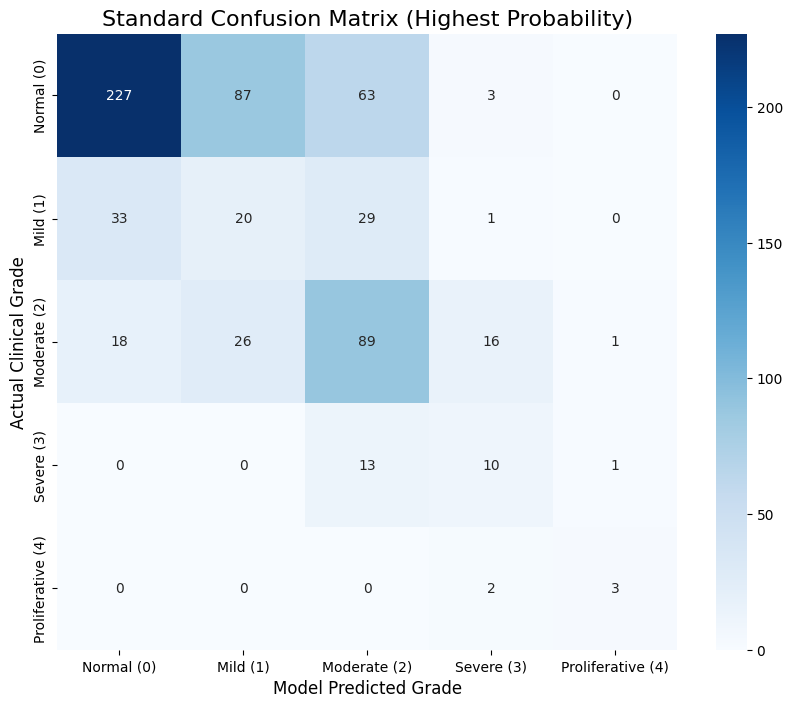


--- Standard Performance Report ---
Overall Accuracy: 54.36%

Detailed Metrics:
                   precision    recall  f1-score   support

       Normal (0)       0.82      0.60      0.69       380
         Mild (1)       0.15      0.24      0.19        83
     Moderate (2)       0.46      0.59      0.52       150
       Severe (3)       0.31      0.42      0.36        24
Proliferative (4)       0.60      0.60      0.60         5

         accuracy                           0.54       642
        macro avg       0.47      0.49      0.47       642
     weighted avg       0.63      0.54      0.57       642



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. GENERATE RAW PREDICTIONS
# is_training=False ensures the data isn't shuffled, so labels match perfectly
eval_gen = multimodal_generator(val_df, val_datagen, VAL_IMG_DIR, BATCH_SIZE, is_training=False)

print("Generating standard predictions...")
y_probs = model.predict(eval_gen, steps=len(val_df) // BATCH_SIZE + 1)

# Align predictions and ground truth lengths
y_probs = y_probs[:len(val_df)]
y_true = val_df['Grade'].astype(int).values

# 2. APPLY STANDARD ARGMAX (The "Normal" Way)
# This picks the index (0-4) with the highest probability value
y_pred_normal = np.argmax(y_probs, axis=1)

# 3. VISUALIZE CONFUSION MATRIX
class_labels = ['Normal (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']
cm = confusion_matrix(y_true, y_pred_normal)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Standard Confusion Matrix (Highest Probability)', fontsize=16)
plt.ylabel('Actual Clinical Grade', fontsize=12)
plt.xlabel('Model Predicted Grade', fontsize=12)
plt.show()

# 4. FINAL PERFORMANCE REPORT
print("\n--- Standard Performance Report ---")
accuracy = accuracy_score(y_true, y_pred_normal)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Metrics:")
print(classification_report(y_true, y_pred_normal, target_names=class_labels))

In [7]:
from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score

# --- 1. Define the Threshold Logic ---
THRESHOLD_PROLIFERATIVE = 0.25
THRESHOLD_SEVERE = 0.35

def apply_clinical_logic(probs):
    preds = []
    for p in probs:
        if p[4] >= THRESHOLD_PROLIFERATIVE: preds.append(4)
        elif p[3] >= THRESHOLD_SEVERE: preds.append(3)
        else: preds.append(np.argmax(p))
    return np.array(preds)

# --- 2. Generate the missing variable ---
# This creates the 'y_pred_clinical' that the error was complaining about
y_pred_clinical = apply_clinical_logic(y_probs)

# --- 3. Refined Reliability Function ---
def evaluate_reliability(y_true, y_pred, method_name="Clinical"):
    kappa_std = cohen_kappa_score(y_true, y_pred)
    kappa_qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    def get_clinical_label(k):
        if k >= 0.81: return "Almost Perfect Agreement"
        if k >= 0.61: return "Substantial Agreement"
        if k >= 0.41: return "Moderate Agreement"
        if k >= 0.21: return "Fair Agreement"
        return "Slight to Poor Agreement"

    print(f"\n--- {method_name} Reliability Analysis ---")
    print(f"{'Standard Kappa:':<25} {kappa_std:.4f}")
    print(f"{'Weighted Kappa (QWK):':<25} {kappa_qwk:.4f}")
    print(f"{'Clinical Significance:':<25} {get_clinical_label(kappa_qwk)}")

    return kappa_std, kappa_qwk

# --- 4. Execute the evaluation ---
# Now y_pred_clinical is defined and ready to go!
std_k, qwk_k = evaluate_reliability(y_true, y_pred_clinical, method_name="Threshold-Adjusted")


--- Threshold-Adjusted Reliability Analysis ---
Standard Kappa:           0.2920
Weighted Kappa (QWK):     0.5751
Clinical Significance:    Moderate Agreement


In [8]:
# model.summary()